<a href="https://colab.research.google.com/github/eiyu18/MachineLearning/blob/main/JS05/JS05_Lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_repeated=0, shuffle=False)

X = np.absolute(X)

X = np.round(X, 2) * 100

X = X.astype(int)

print(X)
print(y)

[[133 134]
 [  6   5]
 [ 76  75]
 [ 76  78]
 [ 70  66]
 [170 170]
 [217 222]
 [ 79  79]
 [121 224]
 [ 95  26]
 [208  62]
 [ 22 222]
 [167  95]
 [ 64 242]
 [160  66]
 [ 26 330]
 [126  91]
 [157  73]
 [241   4]
 [110 186]
 [100  60]
 [125 103]
 [ 83  47]
 [159 227]
 [ 86 188]
 [144 278]
 [144 229]
 [104  25]
 [ 28 163]
 [ 14  20]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [3]:
import pandas as pd

y_new = y.reshape(len(y), 1)

data = np.concatenate((X, y_new), axis=1)

nama_kolom = ['Feature 1', 'Feature 2', 'Label']

df = pd.DataFrame(data, columns=nama_kolom)

df.head()

,Feature 1,Feature 2,Label
0,133,134,0
1,6,5,0
2,76,75,0
3,76,78,0
4,70,66,0


In [4]:
labels = {
    1 : 'Class A',
    0 : 'Class B'
}

df_label = df.copy()

df_label['Label'] = df_label['Label'].map(labels)

df_label.head()

,Feature 1,Feature 2,Label
0,133,134,Class B
1,6,5,Class B
2,76,75,Class B
3,76,78,Class B
4,70,66,Class B


/tmp/ipykernel_4094/2552175783.py:9: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_a = gb.get_group('Class A')
/tmp/ipykernel_4094/2552175783.py:10: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_b = gb.get_group('Class B')


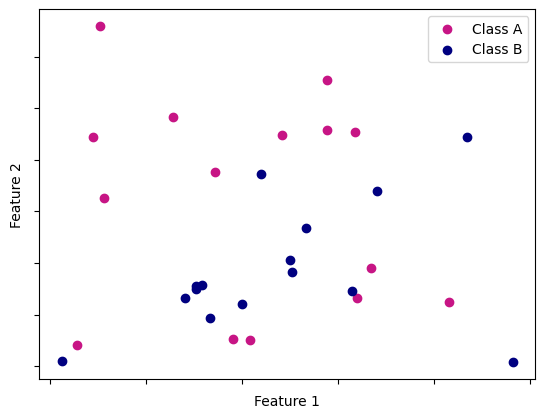

In [7]:
import matplotlib.pyplot as plt

colors = {
    'class_a': 'MediumVioletRed',
    'class_b': 'Navy'
}

gb = df_label.groupby(['Label'])
class_a = gb.get_group('Class A')
class_b = gb.get_group('Class B')

plt.scatter(x=class_a['Feature 1'], y=class_a['Feature 2'], c=colors['class_a'])
plt.scatter(x=class_b['Feature 1'], y=class_b['Feature 2'], c=colors['class_b'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(['Class A', 'Class B'])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

mnb = MultinomialNB()

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=30)

mnb.fit(X_train, y_train)

y_train_pred = mnb.predict(X_train)

acc_train = accuracy_score(y_train, y_train_pred)

y_test_pred = mnb.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)

print(f'Training accuracy: {acc_train}')
print(f'Test accuracy: {acc_test}')

Training accuracy: 0.5714285714285714
Test accuracy: 0.6666666666666666


In [9]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_train_pred_gnb = gnb.predict(X_train)

acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)

y_test_pred_gnb = gnb.predict(X_test)

acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

print(f'Training accuracy (Gaussian): {acc_train_gnb}')
print(f'Test accuracy (Gaussian): {acc_test_gnb}')

Training accuracy (Gaussian): 0.6666666666666666
Test accuracy (Gaussian): 0.7777777777777778
